In [93]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import ArtistAnimation
from IPython.display import HTML

Initial Condition

Left State:

    rhoL = 1.0 

    velL = 0.0

    preL = 1.0

Right State:

    rhoR = 0.125

    velR = 0.0

    preR = 0.1


In [94]:
def prepareanimation():
    global figA, artistA
    #set up for animation
    figA = plt.figure(figsize=(8,6))
    artistA = []

    plt.xlim(-0.5*1,0.5*1)
    plt.xlabel(r'$x$')

In [95]:
def addanimation(cel_center, rho, u, p, legend):

    global artistA
    
    im1 = plt.plot(cel_center, rho, color='blue',label=r"$\rho$",)
    im2 = plt.plot(cel_center, u, color='red',label=r"$v$",)
    im3 = plt.plot(cel_center, p, color='green',label=r"$P$")

    plt.xlabel(r'$x$')
    plt.xlim(min(cel_center), max(cel_center))
    plt.ylim(-0.1, 1.2)
    
    if legend == 1:
        plt.legend()

    figA.tight_layout()
    artistA.append(im1 + im2 + im3)

In [96]:
def godunov(ist, ien, dt, dx, rho, mom,  ene, frho, fmom, fe):
    
    for i in range(ist, ien-1):
        rho[i] = rho[i] - dt/dx*( frho[i] - frho[i-1] )
        mom[i] = mom[i] - dt/dx*( fmom[i] - fmom[i-1] )
        ene[i] = ene[i] - dt/dx*( fe[i] - fe[i-1] )

In [205]:
def newtoniteration(uL, uR, pR, pL, cL, cR):
    global gamma
    ## vL(p)=vR(p)
    #f(p) = vL(p) - vR(p)
    gamma = 1.4

    p_i = abs(( cR*pL + cL*pR - cR*cL*(uR - uL) )/(cR + cL))

    delta_p = 10
    dp_Ldv=0
    dp_Rdv=0
    vL = 0
    vR = 0
    
    while abs(delta_p/p_i) > 1e-4:
        mass_flux_L = np.sqrt(0.5*cL**2*((gamma+1)*p_i/pL + (gamma -1))/gamma)
        dp_Ldv = 2*mass_flux_L**3/(mass_flux_L**2 + cL**2)
        
        
        mass_flux_R = np.sqrt(0.5*cR**2*((gamma+1)*p_i/pR + (gamma -1))/gamma)
        dp_Rdv = 2*mass_flux_R**3/(mass_flux_R**2 + cR**2)
        
        vL = uL - (p_i - pL)/(mass_flux_L)
        vR = uR + (p_i - pR)/(mass_flux_R) 

        denom = dp_Ldv + dp_Rdv
        if abs(denom) < 1e-12:
            print("WARNING: denominator too small")
            break

        delta_p = dp_Ldv* dp_Rdv*(vR - vL)/ (dp_Ldv + dp_Rdv)
        p_i = p_i - delta_p
    
    v_i =  (dp_Ldv*vL+ dp_Rdv*vR)/(dp_Ldv + dp_Rdv) 
    
    return p_i,  v_i

In [206]:
def hllc(rhoL, uL, pL, rhoR, uR, pR):

    global gamma

    rhoL = rhoL
    uL = uL
    pL = pL 

    rhoR = rhoR
    uR = uR
    pR = pR

    gamma = 1.4
   
    s = np.zeros(3)

    cL = np.sqrt(gamma*pL*rhoL)

    cR = np.sqrt(gamma*pR*abs(rhoR))
    
    #print(rhoR)  
    p_star, v_star = newtoniteration(uL, uR, pR, pL, cL, cR)
    
    aL = np.sqrt(gamma * pL / rhoL)
    aR = np.sqrt(gamma * pR / rhoR)
    
    if p_star >= pL: #shock
        s[0] = uL - aL*np.sqrt( ( (gamma + 1)*p_star/pL + (gamma+1) )/(2.0*gamma) )
        rho_star_l = rhoL*(p_star/pL + (gamma-1)/(gamma+1))/( (gamma-1)/(gamma+1)*p_star/pL + 1.0)
    else: #rarefaction
        s[0] = 0.5*( uL - aL + v_star - np.sqrt(gamma*p_star/rhoL) )
        rho_star_l = rhoL * (p_star/pL)**(1/gamma)

    if p_star >= pR: #shock
        s[2] = uR + aR*np.sqrt( ( (gamma + 1)*p_star/pR + (gamma+1) )/(2.0*gamma) )
        rho_star_r = rhoR*(p_star/pR + (gamma-1)/(gamma+1))/( (gamma-1)/(gamma+1)*p_star/pR + 1.0)
    else: #rarefaction
        s[2] = 0.5*( uR + aR + v_star + np.sqrt(gamma*p_star/rhoR) )
        rho_star_r = rhoR * (p_star/pR)**(1/gamma)


    #s[0] = min(uL - np.sqrt(gamma*pL/rhoL), uR - np.sqrt(gamma*pR/rhoR))
    #s[2] = max(uL + np.sqrt(gamma*pL/rhoL), uR + np.sqrt(gamma*pR/rhoR))
    s[1] = v_star


    if s[0] >= 0: #wL
        frho =  rhoL * uL
        fmom= rhoL * uL**2 + pL
        fe = (gamma*pL/(gamma-1) + 0.5*rhoL*uL**2) * uL
    elif s[0]<=0 and s[1] >= 0: #wL*
        frho =  rho_star_l * v_star
        fmom= rho_star_l * v_star**2 + p_star
        fe = (gamma*p_star/(gamma-1) + 0.5*rho_star_l*v_star**2) * v_star

    elif s[1]<= 0 and s[2] >= 0: #wR*
        frho =  rho_star_r * v_star
        fmom= rho_star_r * v_star**2 + p_star
        fe = (gamma*p_star/(gamma-1) + 0.5*rho_star_r*v_star**2) * v_star

    else:  #wR
        frho =  rhoR * uR
        fmom= rhoR * uR**2 + pR
        fe = (gamma*pR/(gamma-1) + 0.5*rhoR*uR**2) * uR

    return frho, fmom, fe

/var/folders/xc/ym24bbrn1lb7fnzh8tj6vqhw0000gn/T/ipykernel_2083/1772433460.py:97: RuntimeWarning: invalid value encountered in sqrt
  dt = cfl*dx/min( np.sqrt(gamma*p[ist:ien]/rho[ist:ien ]) + abs(u[ist:ien]))
/var/folders/xc/ym24bbrn1lb7fnzh8tj6vqhw0000gn/T/ipykernel_2083/568727257.py:19: RuntimeWarning: invalid value encountered in sqrt
  cR = np.sqrt(gamma*pR*abs(rhoR))


ZeroDivisionError: division by zero

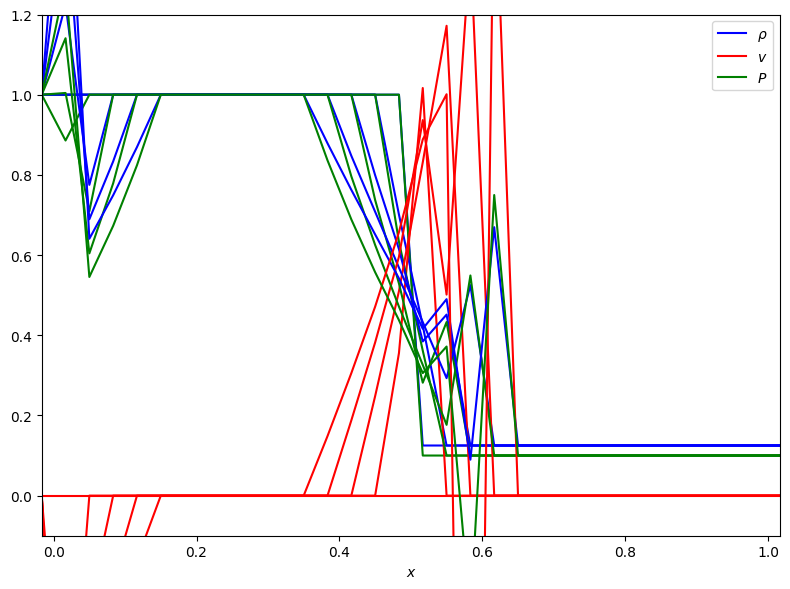

In [ ]:
def shocktube1d(rhoL,velL,preL,rhoR,velR,preR):
    
    global ist, ien, dx, ntot, gamma

    #initial conditions
    rhoL = rhoL 
    uL = velL
    pL = preL

    rhoR = rhoR
    uR = velR
    pR = preR

    ngrids = 30
    L = 1.0
    dx = L / ngrids
    cfl = 0.8
    gamma = 1.4
     
    ist = 1
    nghost = ist
    ien = ngrids + nghost
    ntot = ngrids + 2*nghost
    cfl = 0.8

    rho = np.zeros(ntot)
    u = np.zeros(ntot)
    p = np.zeros(ntot)

    #fluxes
    global frho, frhou, fe
    frho = np.zeros(ntot)
    fmom = np.zeros(ntot)
    fe = np.zeros(ntot)

    mom = np.zeros(ntot)
    ene = np.zeros(ntot)

    time = 0
    tout = 0.2

    prepareanimation()


    cel_center = np.zeros(ntot)
    cel_boundary = np.zeros(ntot+1)

    for i in range(ntot +1):
        cel_boundary[i] = (i - ist) * dx

    for i in range(ntot):
        cel_center[i] = 0.5*(cel_boundary[i] + cel_boundary[i+1])

    #profile at t = 0
    x0 = ngrids//2.0 # center of the shock tube
   
    for i in range(ntot):

        if i <= x0:
            rho[i] = rhoL
            u[i] = uL
            p[i] = pL

        else:
            rho[i] = rhoR
            u[i] = uR
            p[i] = pR

        mom[i] = rho[i]*u[i]
        ene[i] = p[i]/(gamma-1) + 0.5*rho[i]*u[i]**2

    addanimation(cel_center, rho, u, p,1)

    dt = cfl*dx/min( np.sqrt(gamma*p[ist:ien]/rho[ist:ien ]) + abs(u[ist:ien]))

    while time < tout:
        
        for i in range(ist, ien-1):
            frho[i], fmom[i], fe[i] = hllc(rho[i], u[i], p[i], rho[i+1], u[i+1], p[i+1])

        
        godunov(ist, ien, dt, dx, rho, mom,  ene, frho, fmom, fe)

        for i in range(ist, ien-1):
            u[i] = mom[i]/rho[i]
            p[i] = (gamma-1)*(ene[i] - 0.5*rho[i]*u[i]**2)  #(ene[i] - 0.5*mom[i]*u[i])/rho[i]
        
        addanimation(cel_center, rho, u, p,0)

        dt = cfl*dx/min( np.sqrt(gamma*p[ist:ien]/rho[ist:ien ]) + abs(u[ist:ien]))
        time = time + dt

        if  time + dt > tout:
            dt = tout - time
        
    addanimation(cel_center, rho, u, p,0)

if __name__ == "__main__":
    shocktube1d(rhoL = 1.0 ,velL= 0.0, preL=1.0 ,rhoR=0.125 ,velR=0.0 ,preR=0.1)

anim = ArtistAnimation(figA, artistA, interval=50) 
HTML(anim.to_jshtml())  